# Generic Research Run Viewer

Reusable viewer for any run directory that contains:
- `summary.csv`
- optional `by_date.csv` or `by_trade.csv`
- optional `params.json` and `manifest.json`

This notebook now supports both multi-row horizon summaries and single-row research summaries such as overnight close-to-next-open tests.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from research.common.research_run_viewer import (
    discover_run_dirs,
    first_existing,
    is_single_row_summary,
    load_run_artifacts,
    multi_row_metric_groups,
    single_row_metric_groups,
)

pd.set_option('display.max_columns', 200)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
RUNS_ROOT = Path('../research/output')
run_dirs = discover_run_dirs(RUNS_ROOT)

recent = run_dirs[:10]
display(Markdown('## Recent Runs'))
display(pd.DataFrame([
    {
        'run_tag': d.name,
        'modified_time': pd.to_datetime(d.stat().st_mtime, unit='s').strftime('%Y-%m-%d %H:%M:%S'),
        'has_by_date': (d / 'by_date.csv').exists(),
        'has_by_trade': (d / 'by_trade.csv').exists(),
        'path': str(d),
    }
    for d in recent
]) if recent else pd.DataFrame({'message': ['No run directories found']}))

RUN_TAG = None  # Optional override
SELECTED_RUN = RUN_TAG or (recent[0].name if recent else None)
if SELECTED_RUN is None:
    raise FileNotFoundError('No run found. Generate research outputs first.')

RUN_DIR = RUNS_ROOT / SELECTED_RUN
print(f'Using run: {SELECTED_RUN}')
print(f'Run dir: {RUN_DIR.resolve()}')

## Recent Runs

,run_tag,modified_time,has_by_date,has_by_trade,path
0,xlk_xle_50_50_latest_20260722,2026-07-22 23:14:31,True,True,../research/output/xlk_xle_50_50_latest_20260722
1,xlk_xle_quarterly_50_50_20260627,2026-06-28 14:00:00,True,True,../research/output/xlk_xle_quarterly_50_50_202...
2,tsla_spy_long_20260622,2026-06-22 16:28:03,False,False,../research/output/tsla_spy_long_20260622
3,tsla_spy_full_20260622,2026-06-22 16:25:00,False,False,../research/output/tsla_spy_full_20260622
4,tqqq_spy_quarterly_100_000_20260610,2026-06-13 15:52:24,True,True,../research/output/tqqq_spy_quarterly_100_000_...
5,tqqq_spy_quarterly_000_100_20260610,2026-06-13 15:52:24,True,True,../research/output/tqqq_spy_quarterly_000_100_...
6,xlk_xle_quarterly_100_000_20260610,2026-06-10 23:36:25,True,True,../research/output/xlk_xle_quarterly_100_000_2...
7,xlk_xle_quarterly_090_010_20260610,2026-06-10 23:36:25,True,True,../research/output/xlk_xle_quarterly_090_010_2...
8,xlk_xle_quarterly_080_020_20260610,2026-06-10 23:36:24,True,True,../research/output/xlk_xle_quarterly_080_020_2...
9,xlk_xle_quarterly_070_030_20260610,2026-06-10 23:36:23,True,True,../research/output/xlk_xle_quarterly_070_030_2...


Using run: xlk_xle_50_50_latest_20260722
Run dir: /home/rockebull/proj/TradingAgents/research/output/xlk_xle_50_50_latest_20260722


In [3]:
artifacts = load_run_artifacts(RUN_DIR)
summary = artifacts.summary
by_date = artifacts.by_date
by_trade = artifacts.by_trade
params = artifacts.params
manifest = artifacts.manifest

summary_display = summary if not is_single_row_summary(summary) else summary.iloc[0].to_frame('value')

display(Markdown('## Summary'))
display(summary_display)

if params:
    display(Markdown('## Params'))
    display(pd.DataFrame({'parameter': list(params.keys()), 'value': list(params.values())}))
if manifest:
    display(Markdown('## Manifest'))
    display(pd.DataFrame({'field': list(manifest.keys()), 'value': [manifest[k] for k in manifest.keys()]}))

## Summary

,value
symbol_a,XLK
symbol_b,XLE
weight_a,0.5
weight_b,0.5
start_date,2010-06-29
end_date,2026-07-22
rebalance_frequency,quarterly
days_tested,4040
rebalance_count,66
gross_total_return,10.6176


## Params

,parameter,value
0,script,quarterly_mixed_etf_portfolio
1,symbol_a,XLK
2,symbol_b,XLE
3,weight_a,0.5
4,weight_b,0.5
5,start_date,2010-06-29
6,end_date,2026-07-22
7,transaction_cost_bps_per_side,0.0
8,net_total_return,10.6176
9,net_sharpe,0.831779


## Manifest

,field,value
0,run_tag,xlk_xle_50_50_latest_20260722
1,created_at_utc,2026-07-22T23:14:31.980032+00:00
2,command,research/quarterly_mixed_etf_portfolio.py --sy...
3,python_version,3.13.14
4,git_head,0d7340f2729d15b80d4236828520aba574054808
5,config_json,None
6,artifacts,{'summary_csv': 'research/output/xlk_xle_50_50...


## Summary Plots

The notebook uses different plot layouts for single-row summaries versus multi-row horizon diagnostics.

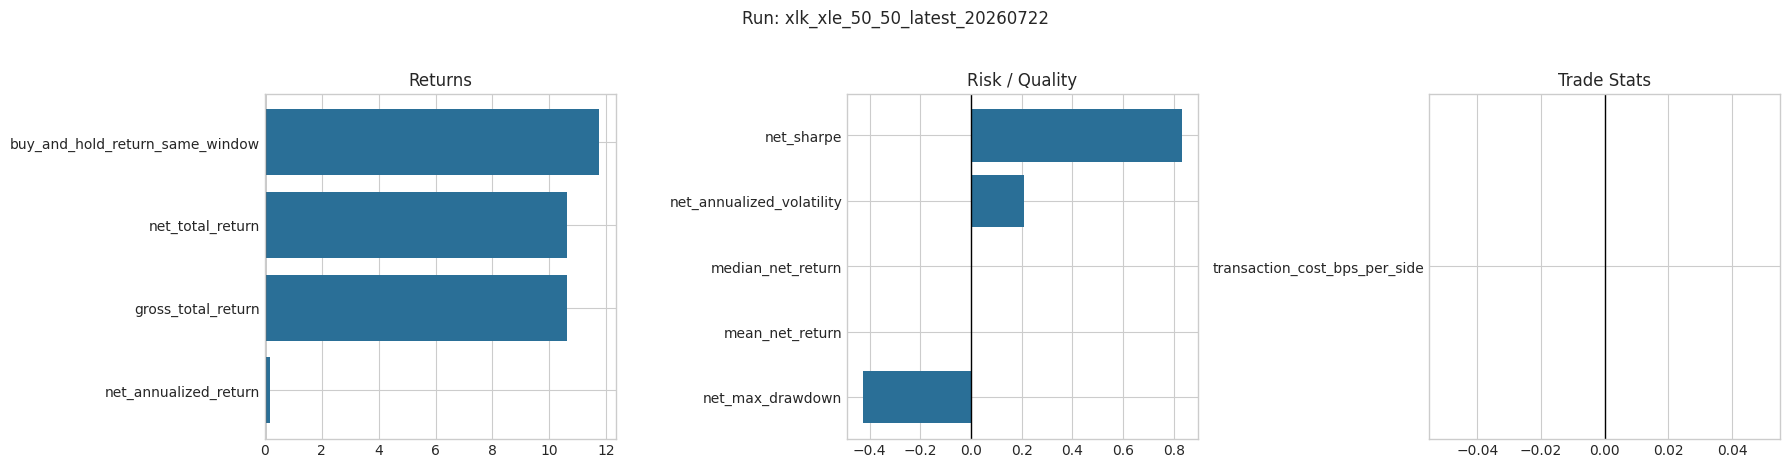

In [4]:
if summary.empty:
    display(Markdown('Summary is empty.'))
elif is_single_row_summary(summary):
    groups = single_row_metric_groups(summary)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    row = summary.iloc[0]
    for ax, (title, cols) in zip(axes, groups.items()):
        if cols:
            values = pd.to_numeric(row[cols], errors='coerce').dropna().sort_values()
            ax.barh(values.index, values.values, color='#2a6f97')
            ax.axvline(0, color='black', linewidth=1)
        else:
            ax.text(0.5, 0.5, 'No matching metrics', ha='center', va='center')
            ax.set_axis_off()
        ax.set_title(title)
    fig.suptitle(f'Run: {SELECTED_RUN}', y=1.03)
    fig.tight_layout()
    plt.show()
else:
    h_col = first_existing(summary, ['horizon_days', 'horizon', 'h'])
    x = summary[h_col].astype(str) if h_col else summary.index.astype(str)
    groups = multi_row_metric_groups(summary)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    for ax, (title, cols) in zip(axes, groups.items()):
        plotted = False
        for col in cols:
            y = pd.to_numeric(summary[col], errors='coerce')
            if y.notna().any():
                ax.plot(x, y, marker='o', label=col)
                plotted = True
        if title != 'Implementation / Breadth':
            ax.axhline(0, color='black', linewidth=1)
        ax.set_title(title)
        if plotted:
            ax.legend(loc='best')
        else:
            ax.text(0.5, 0.5, 'No matching metrics', ha='center', va='center')
            ax.set_axis_off()

    fig.suptitle(f'Run: {SELECTED_RUN}', y=1.03)
    fig.tight_layout()
    plt.show()

In [5]:
if by_trade is not None and not by_trade.empty:
    display(Markdown('## Trade-Level Review'))
    t = by_trade.copy()
    date_col = first_existing(t, ['exit_date', 'trade_date'])
    t = t.sort_values(date_col)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    if {'equity_curve_net', 'equity_curve_gross'} <= set(t.columns):
        axes[0, 0].plot(t[date_col], t['equity_curve_net'], label='Net equity')
        axes[0, 0].plot(t[date_col], t['equity_curve_gross'], label='Gross equity', linestyle='--')
        axes[0, 0].set_title('Equity Curve')
        axes[0, 0].legend(loc='best')
    else:
        axes[0, 0].text(0.5, 0.5, 'No equity curve columns', ha='center', va='center')
        axes[0, 0].set_axis_off()

    if 'drawdown_net' in t.columns:
        axes[0, 1].plot(t[date_col], t['drawdown_net'], color='#b00020')
        axes[0, 1].axhline(0, color='black', linewidth=1)
        axes[0, 1].set_title('Net Drawdown')
    else:
        axes[0, 1].text(0.5, 0.5, 'No drawdown column', ha='center', va='center')
        axes[0, 1].set_axis_off()

    if 'net_return' in t.columns:
        rolling = pd.to_numeric(t['net_return'], errors='coerce').rolling(50, min_periods=10).mean()
        axes[1, 0].plot(t[date_col], rolling)
        axes[1, 0].axhline(0, color='black', linewidth=1)
        axes[1, 0].set_title('Rolling Mean Net Return (50 trades)')

        axes[1, 1].hist(pd.to_numeric(t['net_return'], errors='coerce').dropna(), bins=40, color='#457b9d', alpha=0.85)
        axes[1, 1].axvline(0, color='black', linewidth=1)
        axes[1, 1].set_title('Net Return Distribution')
    else:
        axes[1, 0].text(0.5, 0.5, 'No net_return column', ha='center', va='center')
        axes[1, 0].set_axis_off()
        axes[1, 1].text(0.5, 0.5, 'No net_return column', ha='center', va='center')
        axes[1, 1].set_axis_off()

    fig.tight_layout()
    plt.show()

    display(Markdown('## Trade Preview'))
    display(t.tail(20))
elif by_date is None or by_date.empty:
    display(Markdown('No `by_date.csv` or `by_trade.csv` available for this run.'))
else:
    display(Markdown('## Date-Level Review'))
    d = by_date.copy().sort_values('date')
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    group_key = 'horizon_days' if 'horizon_days' in d.columns else d.columns[0]
    for horizon, group in d.groupby(group_key):
        group = group.sort_values('date')
        if 'active_return' in group.columns:
            axes[0].plot(group['date'], group['active_return'].cumsum(), label=f'h={horizon}')
        if 'ic' in group.columns:
            axes[1].plot(group['date'], group['ic'].rolling(20, min_periods=5).mean(), label=f'h={horizon}')
        if 'implied_ir_component' in group.columns:
            axes[2].plot(group['date'], group['implied_ir_component'], label=f'h={horizon}', alpha=0.9)

    axes[0].set_title('Cumulative Active Return')
    axes[1].set_title('Rolling IC Mean (20)')
    axes[2].set_title('Implied IR Component')
    axes[2].axhline(0, color='black', linewidth=1)

    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(loc='best')
    fig.tight_layout()
    plt.show()

## Trade-Level Review

KeyError: None